### Homework 2: Exploratory data analysis and visualization

UIC CS 418, Fall 2024

_According to the **Academic Integrity Policy** of this course, all work submitted for grading must be done individually, unless otherwise specified. While we encourage you to talk to your peers and learn from them, this interaction must be superficial with regards to all work submitted for grading. This means you cannot work in teams, you cannot work side-by-side, you cannot submit someone else’s work (partial or complete) as your own. In particular, note that you are guilty of academic dishonesty if you extend or receive any kind of unauthorized assistance. Absolutely no transfer of program code between students is permitted (paper or electronic), and you may not solicit code from family, friends, or online forums. Other examples of academic dishonesty include emailing your program to another student, copying-pasting code from the internet, working in a group on a homework assignment, and allowing a tutor, TA, or another individual to write an answer for you. Academic dishonesty is unacceptable, and penalties range from failure to expulsion from the university; cases are handled via the official student conduct process described at https://dos.uic.edu/conductforstudents.shtml._

This homework is an **individual assignment for all students**.

There are four parts in this homework. The first one (Q0) is a practice introduction to `matplotlib` (5%). The second (Q1.1-Q1.5) is a guided exploration of a google_play dataset (40%). The third one (Q2.0-Q2.4) is a self-guided exploration of a dataset on religious composition of the world’s migrants (45%). The forth one (Q3.1-3.3) is Hypothesis testing practice (10%). You can also earn extra credit of 10%.


## Due Date

This assignment is due at 11:59pm October 17th, 2024. 


### What to Submit

You need to complete all code and answer all questions denoted by **Q#** (each one is under a bike image) in this notebook. When you are done, you should export **hw2.ipynb** with your answers as a PDF file, upload the PDF file to *Homework 2 - Written Part* on Gradescope, tagging each question. You need to upload a completed Jupyter notebook (hw2.ipynb file) to *Homework 2 - code* on Gradescope. If one of these two parts (written and code) is missing, you will lose 50%.

#### Autograding

We will not use autograding for this homework assignment.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm



sns.set_style('whitegrid')



# Practice: `matplotlib` (5%)

[`matplotlib`][mpl] is the most widely used plotting library available for Python. It comes with a good amount of out-of-the-box functionality and is highly customizable. Most other plotting libraries in Python provide simpler ways to generate complicated `matplotlib` plots, including `seaborn`, so it's worth learning a bit about `matplotlib` now.

Notice how all of our notebooks have lines that look like:

	%matplotlib inline
	import matplotlib.pyplot as plt
	
The `%matplotlib inline` magic command tells `matplotlib` to render the plots
directly onto the notebook (by default it will open a new window with the plot).

Then, the `import` line lets us call `matplotlib` functions using `plt.<func>`

Here's a graph of `cos(x)` from 0 to 2 * pi.

[mpl]: http://matplotlib.org/

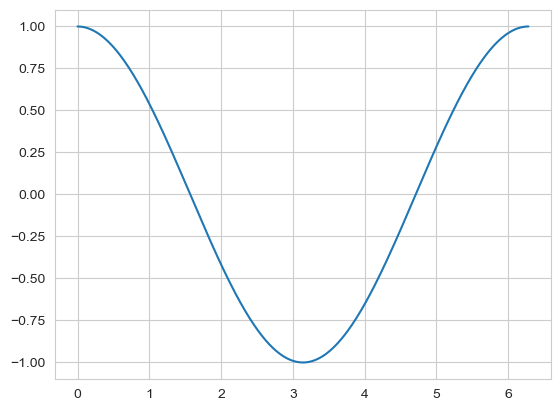

In [2]:
# Set up (x, y) pairs from 0 to 2*pi
xs = np.linspace(0, 2 * np.pi, 300)
ys = np.cos(xs)

# plt.plot takes in x-values and y-values and plots them as a line
plt.plot(xs, ys)

`matplotlib` also conveniently has the ability to plot multiple things on the same plot. Just call `plt.plot` multiple times in the same cell:

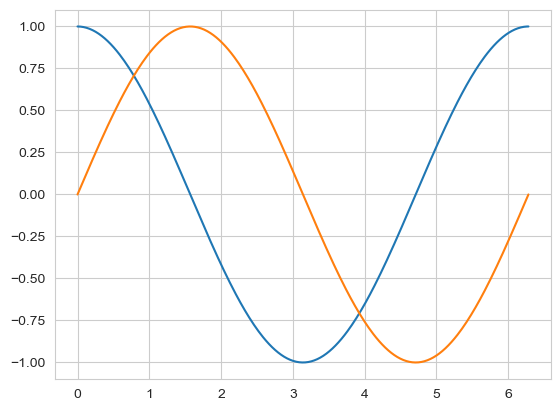

In [3]:
plt.plot(xs, ys)
plt.plot(xs, np.sin(xs))

That plot looks pretty nice but isn't presentation-ready. Luckily, `matplotlib` has a wide array of plot customizations.


## Q0 (5%):

Skim through the first part of the tutorial at https://github.com/rougier/matplotlib-tutorial to create the plot below. There is a lot of extra information there which we suggest
you read on your own time. For now, just look for what you need to make the plot.

Specifically, you'll have to change the x and y limits, add a title, and add a legend.

![](q1.png)

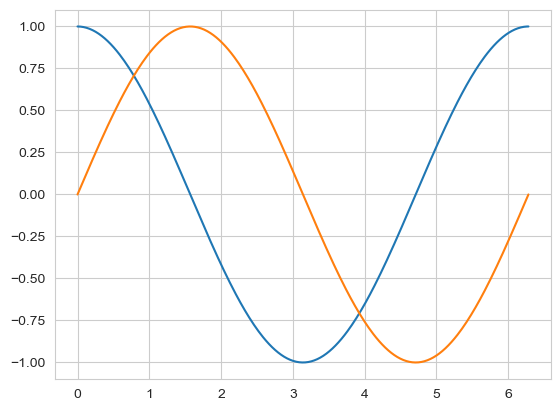

In [4]:
# Here's the starting code from last time. Edit / Add code to create the plot above.
plt.plot(xs, ys)
plt.plot(xs, np.sin(xs))

# Part 1: Guided EDA of google play store apps (40%)

You will be performing some basic EDA (exploratory data analysis) on Google Play Store apps data. Feel free to edit code for clearning the data.


In [5]:
google_play = pd.read_csv('googleplaystore.csv')

# You may drop rows where Rating is NaN to avoid issues 
google_play = google_play.dropna(subset=['Rating'])
google_play['Rating'] = pd.to_numeric(google_play['Rating'], errors='coerce')
google_play['Reviews'] = pd.to_numeric(google_play['Reviews'], errors='coerce')
google_play['Last Updated'] = pd.to_datetime(google_play['Last Updated'], errors='coerce')
google_play = google_play[google_play['Category'] != '1.9']

In [6]:
google_play.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


## Q1.1 (8%):
Explore the `google_play` dataframe to answer the following questions.

What is the data granularity?
What time range is represented here? Write code in the cell below to perform your exploration.

In [7]:
# The data granularity
Unique_google_play = google_play.pivot_table(
    values='Last Updated',  # Use any column that has values for each row
    index='App',  # Group by 'Category' or any other column to assess granularity
    aggfunc='count'  # Count the number of entries per group
)

#print(Unique_google_play)
print(f"The data granularity of unique apps: {len(Unique_google_play)}")
print(f"Total number of rows: {len(google_play)}")

# The time range
min_date = google_play['Last Updated'].min()
max_date = google_play['Last Updated'].max()

print(f"The time range is from: {min_date} - {max_date}")
print(f"The time range represents the time period during which these apps were last updated.")


The data granularity of unique apps: 8196
Total number of rows: 9366
The time range is from: 2010-05-21 00:00:00 - 2018-08-08 00:00:00
The time range represents the time period during which these apps were last updated.


(_Your Q1.1 answer here. Double click to edit_)

## Using `pandas` to plot

`pandas` provides useful methods on dataframes. For simple plots, we prefer to
just use those methods instead of the `matplotlib` methods since we're often
working with dataframes anyway. The syntax is:

    dataframe.plot.<plotfunc>

Where the `<plotfunc>` is one of the functions listed under _Plotting_ here: https://pandas.pydata.org/pandas-docs/stable/reference/frame.html

<Axes: xlabel='Last Updated'>

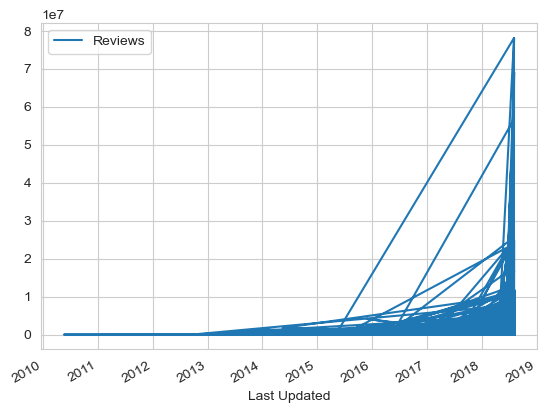

In [8]:
# This plot shows the trend of app ratings over time

google_play.plot.line(x='Last Updated', y='Reviews')

## `seaborn`

Now, we'll learn how to use the [`seaborn`][sns] Python library. `seaborn`
is built on top of `matplotlib` and provides many helpful functions
for statistical plotting that `matplotlib` and `pandas` don't have.

Generally speaking, we'll use `seaborn` for more complex statistical plots,
`pandas` for simple plots (eg. line / scatter plots), and
`matplotlib` for plot customization.

Nearly all `seaborn` functions are designed to operate on `pandas`
dataframes. Most of these functions assume that the dataframe is in
a specific format called *long-form*, where each column of the dataframe
is a particular feature and each row of the dataframe a single datapoint.

For example, this dataframe is long-form:

```
   country year avgtemp
 1  Sweden 1994       6
 2 Denmark 1994       6
 3  Norway 1994       3
 4  Sweden 1995       5
 5 Denmark 1995       8
 6  Norway 1995      11
 7  Sweden 1996       7
 8 Denmark 1996       8
 9  Norway 1996       7
```

But this dataframe of the same data is not:

```
   country avgtemp.1994 avgtemp.1995 avgtemp.1996
 1  Sweden            6            5            7
 2 Denmark            6            8            8
 3  Norway            3           11            7
```

Note that the `google_play` dataframe is long-form.

For more about long-form data, see https://stanford.edu/~ejdemyr/r-tutorials/wide-and-long.
For now, just remember that we typically prefer long-form data and it makes plotting using
`seaborn` easy as well.

[sns]: http://seaborn.pydata.org/index.html

We can create the same plot as the `dataframe.plot` above using the following `seaborn` function: `sns.lineplot`. Notice that instead of calling the plot function on dataframe object, here we pass it as a parameter to the function:

<Axes: xlabel='Last Updated', ylabel='Reviews'>

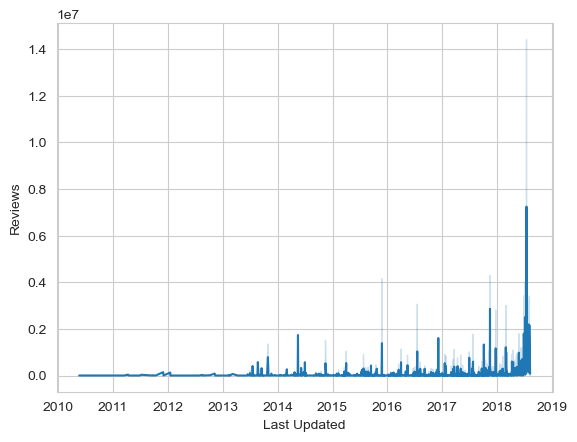

In [9]:
# You can create a plot similar to the one above using the following seaborn syntax
# Note that the seaborn plot is a bit different and requires some customizations (more on this later)
sns.lineplot(x="Last Updated", y="Reviews", data=google_play)

## Q1.2 (8%):

Use seaborn's barplot function to make a bar chart showing the average rating for each app category over the entire `google_play` dataset. Here's a link to the seaborn API:

Here's a link to the seaborn API: http://seaborn.pydata.org/api.html

See if you can figure it out by reading the docs. 

What trends do you notice? What do you suppose causes these trends?

Notice that `barplot` draws error bars for each category. It uses bootstrapping to make those.

The most app categories have high average ratings, generally around 4.0 to 4.5.
This trend maybe caused by the frequencey od update to improve the quality of app.


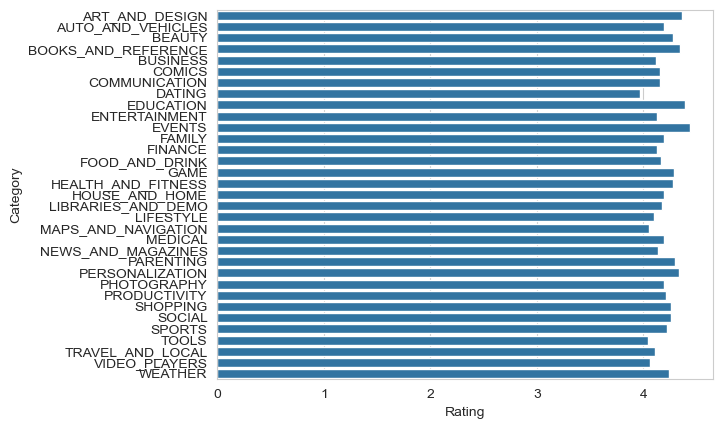

In [10]:
# Get the average rating for each app category over the entire `google_play` 
Average_google_play = google_play.pivot_table(
    values='Rating',  # Use any column that has values for each row
    index='Category',  # Group by 'Category' or any other column to assess granularity
    aggfunc='mean'  # Count the number of entries per group
)
sns.barplot(Average_google_play, x="Rating", y="Category", errorbar=None)
print(f"The most app categories have high average ratings, generally around 4.0 to 4.5.")
print(f"This trend maybe caused by the frequencey od update to improve the quality of app.")


(Your Q1.2 answer here)
The most app categories have high average ratings, generally around 4.0 to 4.5.
This trend maybe caused by the frequencey od update to improve the quality of app.

## Q1.3 (8%):

Now for a fancier plot that `seaborn` makes really easy to produce.

Use the `displot` function to plot a histogram of all the ratings in the `google_play` dataset. Can you fit a curve to the histogram of the data using `seaborn`? You just need to tune `kde` and `stat` paramaters to the `displot` function. Fancy!

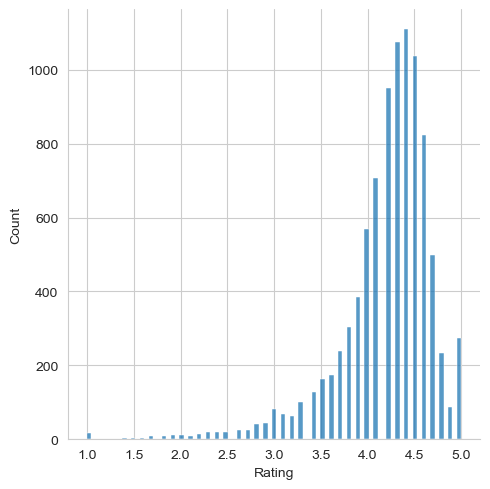

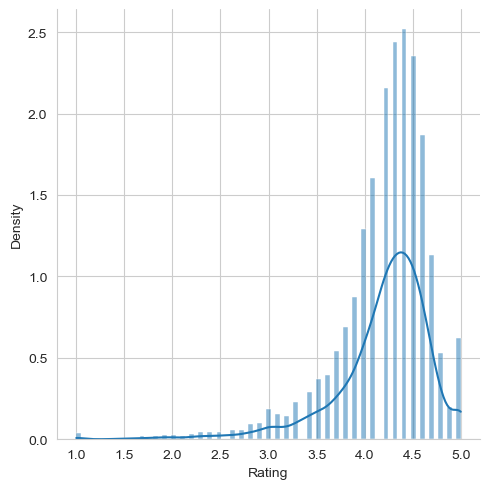

In [11]:
# Plot a histogram of all the ratings in the `google_play` dataset
sns.displot(data=google_play, x="Rating")

# fit a curve to the histogram of the data
sns.displot(data=google_play, x="Rating",kde=True,stat="density")

## Q1.4 (8%):

Use `seaborn` to make side-by-side boxplots of the number of reviews and app size for the apps in the `google_play` dataset. The `boxplot` function will plot all the columns of the dataframe you pass in.

Note that, you may need to pre-process the 'Size' column for numeric analysis. Hint: you may want to convert kb to mb.

Once you make the plot, you'll notice that there are many outliers that make the plot hard to see. To mitigate this, change the y-scale to be logarithmic.

That's a plot customization so you'll use `matplotlib`. The `boxplot` function returns a `matplotlib` Axes object which represents a single plot and has a `set_yscale` function.

The result (after customization) should look like:

![](q1-4.png)

Revisiting Q1.1 on data granularity, what is more suitable text for `ylabel` here than `Number of reviews`?

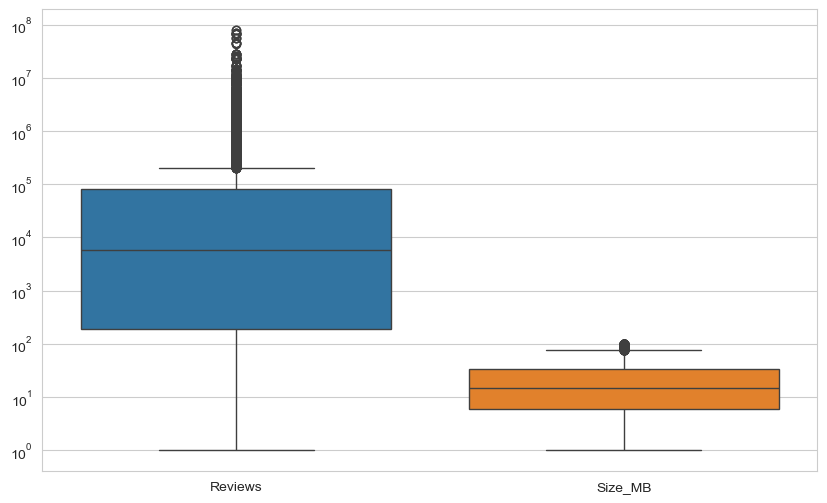

In [12]:
# pre-process the 'Size' column for numeric analysis
google_play['Size'] = google_play['Size'].astype(str)
google_play['Size'] = google_play['Size'].replace('Varies with device', None)

sizes_mb = []
for x in google_play['Size']:
    if 'M' in str(x):
        sizes_mb.append(float(x.replace('M', '')))
    elif 'K' in str(x):
        sizes_mb.append(float(x.replace('M', ''))//1024)
    else:
        sizes_mb.append(None)

google_play['Size_MB'] = pd.to_numeric(sizes_mb, errors='coerce')

# Creating side-by-side boxplots for Review and Size
plt.figure(figsize=(10, 6))
sns.boxplot(data=google_play[['Reviews', 'Size_MB']])
# change the y-scale to be logarithmic.
plt.yscale('log')
plt.show()



## Q1.5 (8%):

Let's take a closer look at the number of reviews vs. rating.

Use the `lmplot` function to make a scatterplot. Put the number of reviews on the x-axis and the rating on the y-axis.
Each point should correspond to a single row in your `google_play` dataframe. Notice that `seaborn` automatically fits a line of best fit to the plot. Does that line seem to be relevant?

You should note that `lmplot` allows you to pass in `fit_reg=False` to avoid plotting lines of best fit when you feel they are unnecessary or misleading.

There seem to be two main groups in the scatterplot. Let's see if we can separate them out. Use `lmplot` to make the scatterplot again. This time, use the `hue` parameter to color points for free apps differently from paid apps.

Note that, you may need to pre-process the 'Type' column, only keep rows where 'Type' is "Free" or "Paid".

You should get something that looks like:

![](q1-5.png)


In [13]:
# Hint: Use log number of reviews makes it easier to observe the app data
# so you may want to use 'Log_Reviews' for this question
google_play['Log_Reviews'] = np.log1p(google_play['Reviews'])

Yes, I think this line is relevant. the line of best fit shows a trend where the rating increases with the number of reviews for both free and paid apps. 


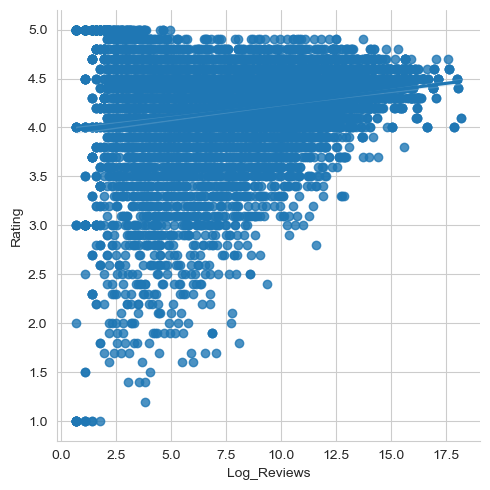

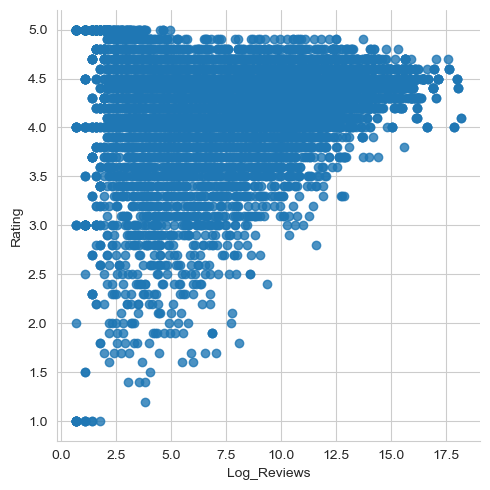

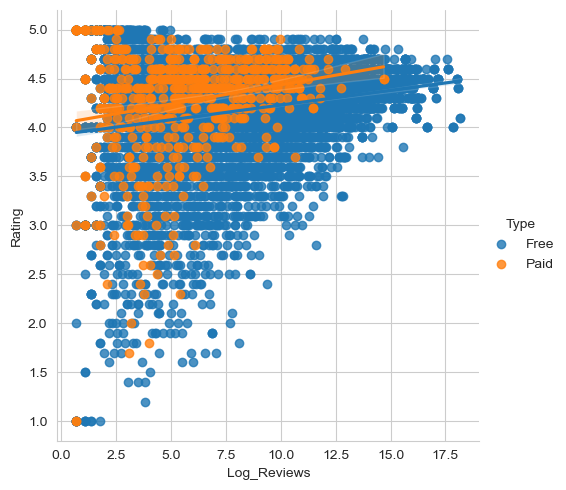

In [14]:
# Scatterplot with plotting lines
sns.lmplot(data=google_play, x="Log_Reviews", y="Rating")
# Scatterplot without plotting lines
sns.lmplot(data=google_play, x="Log_Reviews", y="Rating",fit_reg=False)
# Scatterplot with different color
sns.lmplot(data=google_play, x="Log_Reviews", y="Rating",hue="Type")

print(f"Yes, I think this line is relevant. the line of best fit shows a trend where the rating increases with the number of reviews for both free and paid apps. ")

## Want to learn more?

We recommend checking out the `seaborn` tutorials on your own time. http://seaborn.pydata.org/tutorial.html

The `matplotlib` tutorial we linked in Question 1 is also a great refresher on common `matplotlib` functions: https://www.labri.fr/perso/nrougier/teaching/matplotlib/

Here's a great blog post about the differences between Python's visualization libraries:
https://dansaber.wordpress.com/2016/10/02/a-dramatic-tour-through-pythons-data-visualization-landscape-including-ggplot-and-altair/


# Part 2: Self-directed EDA of Religious composition of the world’s migrants (40%)

The last part is intentionally more open-ended and will be graded on the completeness of the plot(s) produced and the insights you gain from them.  The goal here is for you to thoroughly explore a dataset on the religious breakdown of immigrants to, and emigrants from, countries and regions of the world.

_Question 2.0_ is asking you to look at a given visualization and reverse engineer the code that created it. _Question 2.1_ is about _data exploration visualization_ while the other questions are about _data presentation visualization_. Report your three most significant findings (_Q2.2, Q2.3, and Q2.4_). Each finding should have a _visualization headline_  which highlights the main takeaway in 5-15 words, an informative visualization that supports your finding and a _visualization description_, 100-150 words per finding explaining your assumptions and what you have found. For example, the visualization headline could be "?" with the following bar plot visualization:  

<img src="q2-1.png">


The survey data that you will analyze was collected by Pew Research. In order to access it, you need to create an account and download it from [here](https://www.pewresearch.org/dataset/dataset-religious-composition-of-the-worlds-migrants-1990-2020/) (click on "Download Dataset" in upper right corner). The file you will work with is `Incoming and Outgoing Migrant Counts.csv`.

Be sure to consider transformations, subsets, correlations, reference markers, and lines/curves-of-best-fit (as covered in Chapter 6 of PTDS) to reveal the relationship that you are wanting to learn more about.  Also be sure to make plots that are appropriate for the variable types.  For completeness, be explicit about any assumptions you make in your analysis.  An exemplary plot will have:

* A title
* Labelled and appropriately scaled axes
* A legend, if applicable
* A carefully selected color scheme
* A main point, accentuated through design choices



## Q2.0 (10%): Reverse Engineer

Your first step is to load the data from `Incoming and Outgoing Migrant Counts.csv`, and understand what is stored in it. Your assignment is to replicate the bar plot visualization shown above. Notice the labels on x and y axes as well as the legend of the plot to determine the information needed to construct the plot.

                      Region      Religion       Count
0               Asia-Pacific      Buddhist   181130000
1               Asia-Pacific     Christian   383400000
2               Asia-Pacific         Hindu   235830000
3               Asia-Pacific           Jew    11810000
4               Asia-Pacific        Muslim   573790000
5               Asia-Pacific         Other    48520000
6               Asia-Pacific  Unaffiliated   235450000
7                     Europe      Buddhist    19880000
8                     Europe     Christian  1055010000
9                     Europe         Hindu    18310000
10                    Europe           Jew    28780000
11                    Europe        Muslim   211270000
12                    Europe         Other    21040000
13                    Europe  Unaffiliated   367530000
14                    Global      Buddhist   106620000
15                    Global     Christian  1364800000
16                    Global         Hindu   149780000
17        

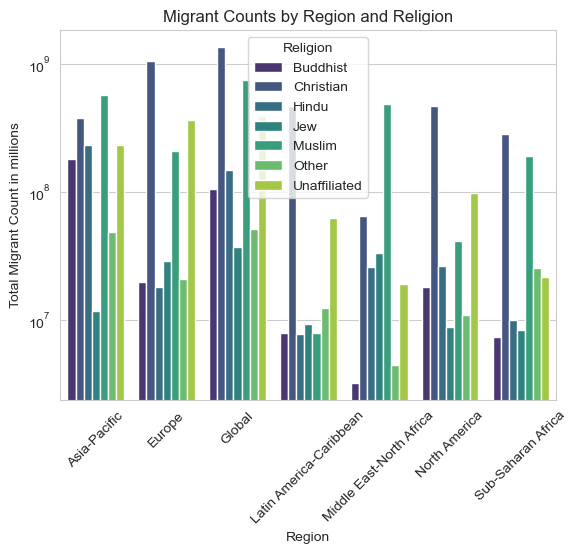

In [15]:
#HINTS
# 1) Read your dataframe with pandas
Incoming_and_Outgoing_Migrant_Count= pd.read_csv('Incoming and Outgoing Migrant Counts.csv')

# 2) Identify what colums are used for plot above
# 3) Filter required rows and columns necessary for plotting above figure
# 4) Pre-process the rows may cause issues
# Hint: there are some values in 'Count' is < 10,000, you can change them to 10,000.
Incoming_and_Outgoing_Migrant_Count['Count'] = Incoming_and_Outgoing_Migrant_Count['Count'].replace('< 10,000', '10000')
Incoming_and_Outgoing_Migrant_Count['Count'] = Incoming_and_Outgoing_Migrant_Count['Count'].str.replace(',', '')  # 移除逗号
Incoming_and_Outgoing_Migrant_Count['Count'] = pd.to_numeric(Incoming_and_Outgoing_Migrant_Count['Count'], errors='coerce')
Incoming_and_Outgoing_Migrant_Count['Percent'] = pd.to_numeric(Incoming_and_Outgoing_Migrant_Count['Percent'], errors='coerce')
Incoming_and_Outgoing_Migrant_Count['level'] = pd.to_numeric(Incoming_and_Outgoing_Migrant_Count['level'], errors='coerce')
Incoming_and_Outgoing_Migrant_Count = Incoming_and_Outgoing_Migrant_Count[Incoming_and_Outgoing_Migrant_Count['Religion'] != 'All']
Incoming_and_Outgoing_Migrant_Count.head()

# 4) Use pandas aggregation to group by Region and Religion and sum the migrant counts
grouped_data = Incoming_and_Outgoing_Migrant_Count.groupby(['Region', 'Religion'], as_index=False)['Count'].sum()
print(grouped_data)

# 5) Use seaborn barplot to plot the figure above. Customize with color palette='viridis'
sns.barplot(grouped_data, x="Region", y="Count", hue="Religion",palette='viridis')

# 6) Add descriptive xlabel, ylabel, and title
plt.title('Migrant Counts by Region and Religion') 
plt.xlabel('Region')
plt.ylabel('Total Migrant Count in millions')
# 7) change the y-scale to be logarithmic for better visualization
plt.yscale('log')  
plt.xticks(rotation=45)
# 8) Customize legend if necessary
plt.legend(title='Religion')
plt.show()



## Q2.1 (5%): Initial exploration

Run descriptive statistics on the data by considering the EDA key data properties we covered in class. Write a 100-150 word description of your findings. Based on these statistics or other ideas you have, form hypotheses that guide your EDA and visualizations for the last three questions. You need to show at least one visualization but you are welcome to show more.

In [16]:
# Run descriptive statistics on the data and develop ideas on what to explore
#Descriptive statistics focuses on summarizing data about a sample drawn from a population
#Measures of central tendency (mean, median, mode)
mean_by_region = grouped_data.groupby('Region')['Count'].mean()
median_by_region = grouped_data.groupby('Region')['Count'].median()
Region_grouped_data = grouped_data.groupby('Region')['Count']
mode_by_region = Region_grouped_data.apply(lambda x: x.mode())
#Measures of dispersion or spread (range, standard deviation, variance)
max_by_region = Region_grouped_data.max()
min_by_region = Region_grouped_data.min()
std_by_region = Region_grouped_data.std()
var_by_region = Region_grouped_data.var()

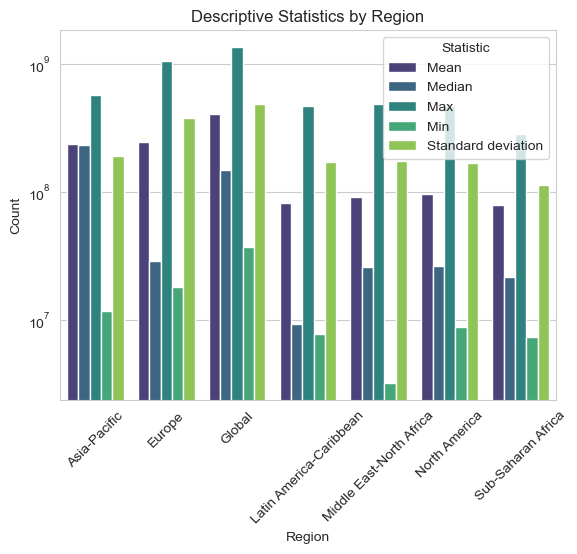

In [17]:
# Create one or more visualizations
mean_by_region = mean_by_region.sort_index()
median_by_region = median_by_region.sort_index()
mode_by_region = mode_by_region.sort_index()
max_by_region = max_by_region.sort_index()
min_by_region = min_by_region.sort_index()
std_by_region = std_by_region.sort_index()
var_by_region = var_by_region.sort_index()

regions = mean_by_region.index

data_by_region = {
    'Region': regions,
    'Mean': mean_by_region.values,
    'Median': median_by_region.values,
    #'Mode': mode_by_region.values,
    'Max': max_by_region.values,
    'Min': min_by_region.values,
    'Standard deviation': std_by_region.values,
    'Variance': var_by_region.values
}

df_region = pd.DataFrame(data_by_region)
df_region_melted = df_region.melt(id_vars='Region', value_vars=['Mean', 'Median', 'Max','Min','Standard deviation'], 
                    var_name='Statistic', value_name='Count')
sns.barplot(x='Region', y='Count', hue='Statistic', data=df_region_melted, palette='viridis')
plt.yscale('log') 
plt.xticks(rotation=45)
plt.title('Descriptive Statistics by Region')
plt.show()


In [18]:
# Run descriptive statistics on the data and develop ideas on what to explore
#Descriptive statistics focuses on summarizing data about a sample drawn from a population
#Measures of central tendency (mean, median, mode)
mean_by_Religion = grouped_data.groupby('Religion')['Count'].mean()
median_by_Religion = grouped_data.groupby('Religion')['Count'].median()
Religion_grouped_data = grouped_data.groupby('Religion')['Count']
mode_by_Religion = Religion_grouped_data.apply(lambda x: x.mode())
#Measures of dispersion or spread (range, standard deviation, variance)
max_by_Religion = Religion_grouped_data.max()
min_by_Religion = Religion_grouped_data.min()
std_by_Religion = Religion_grouped_data.std()
var_by_Religion= Religion_grouped_data.var()

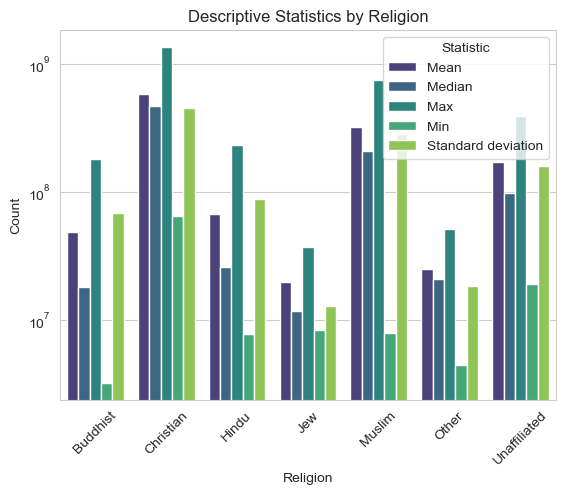

In [19]:
# Create one or more visualizations
mean_by_Religion = mean_by_Religion.sort_index()
median_by_Religion = median_by_Religion.sort_index()
mode_by_Religion = mode_by_Religion.sort_index()
max_by_Religion = max_by_Religion.sort_index()
min_by_Religion = min_by_Religion.sort_index()
std_by_Religion = std_by_Religion.sort_index()
var_by_Religion = var_by_Religion.sort_index()

Religions = mean_by_Religion.index

data_by_Religion = {
    'Religion': Religions,
    'Mean': mean_by_Religion.values,
    'Median': median_by_Religion.values,
    #'Mode': mode_by_region.values,
    'Max': max_by_Religion.values,
    'Min': min_by_Religion.values,
    'Standard deviation': std_by_Religion.values,
    'Variance': var_by_Religion.values
}

df_religion = pd.DataFrame(data_by_Religion)
df_religion_melted = df_religion.melt(id_vars='Religion', value_vars=['Mean', 'Median', 'Max','Min','Standard deviation'], 
                    var_name='Statistic', value_name='Count')
sns.barplot(x='Religion', y='Count', hue='Statistic', data=df_religion_melted, palette='viridis')
plt.yscale('log') 
plt.xticks(rotation=45)
plt.title('Descriptive Statistics by Religion')
plt.show()


Enter your 100-150 word description here.

Descriptive statistics includes Measures of central tendency (mean, median, mode) and Measures of dispersion or spread (range, standard deviation, variance). I count the above statistics by the data groupby Region or Religion. The following is my findings:
1. In the Descriptive Statistics by Region, according to the Max and mean,the The number of immigrants from Europe is the highest.
2. In the Descriptive Statistics by Religion, according to the Max and mean, the number of immigrant which is Christian is the highest.
3. In the Migrant Counts by Region and Religion,Most of the Christian migrants are concentrated in the European region.

## Q2.2 (10%): (_enter your visualization headline here_)

The most immigrants are from Europe, besides Asia-Pacific is also the 2nd migrant region.

                     Region       Count  Proportion
0              Asia-Pacific  1669930000    0.286058
1                    Europe  1721820000    0.294947
3   Latin America-Caribbean   579040000    0.099189
4  Middle East-North Africa   637420000    0.109190
5             North America   678000000    0.116141
6        Sub-Saharan Africa   551520000    0.094475


/var/folders/5p/qvx0rb6n1z32pm4tq8z0r8jm0000gn/T/ipykernel_5505/105732111.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Proportion', data=grouped_data_sum_by_region, palette='viridis')


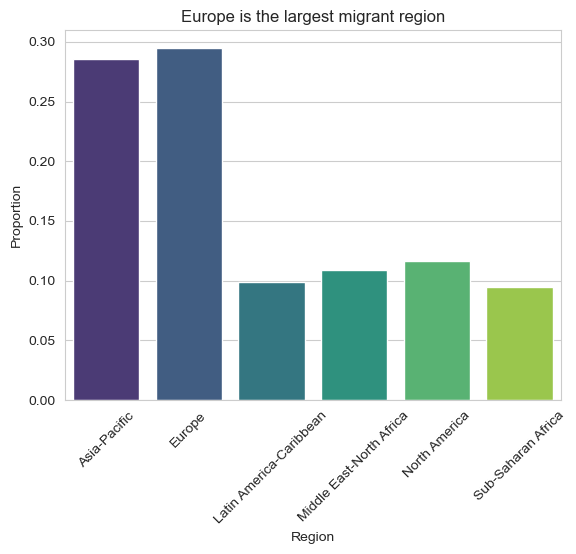

In [20]:
# your Q2.2 visualization code should be included here 
# make sure to execute it, so we can see your plot in the submitted pdf
grouped_data_sum_by_region = Incoming_and_Outgoing_Migrant_Count.groupby(['Region'], as_index=False)['Count'].sum()
grouped_data_sum_by_region = grouped_data_sum_by_region[grouped_data_sum_by_region['Region'] != 'Global']
total_count = grouped_data_sum_by_region['Count'].sum()  # 计算所有区域的移民数总和
grouped_data_sum_by_region['Proportion'] = grouped_data_sum_by_region['Count'] / total_count  # 计算每个区域的比例
print(grouped_data_sum_by_region)
sns.barplot(x='Region', y='Proportion', data=grouped_data_sum_by_region, palette='viridis')
plt.xticks(rotation=45)
plt.title('Europe is the largest migrant region')
plt.show()


## Q2.3 (10%): (_enter your visualization headline here_)

(_enter your visualization description here, replacing this text_)

Christians are the largest migrant group，followed by Muslim and Unaffiliated.

       Religion       Count
0      Buddhist   344230000
1     Christian  4099440000
2         Hindu   474410000
3           Jew   137680000
4        Muslim  2262350000
5         Other   174620000
6  Unaffiliated  1201700000


/var/folders/5p/qvx0rb6n1z32pm4tq8z0r8jm0000gn/T/ipykernel_5505/2143168041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Religion', y='Count', data=grouped_data_sum_by_religion, palette='viridis')


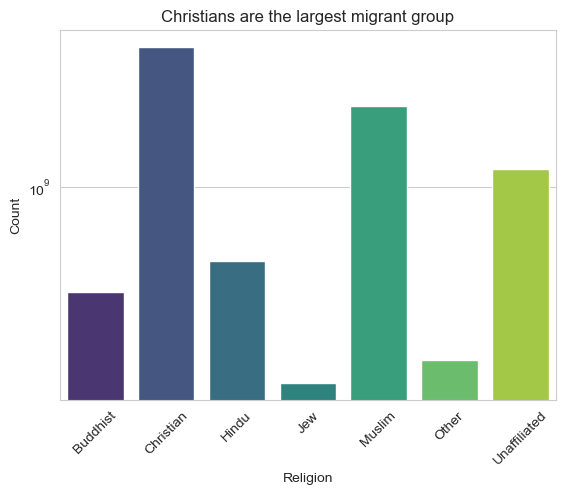

In [21]:
# your Q2.3 visualization code should be included here 
# make sure to execute it, so we can see your plot in the submitted pdf
grouped_data_sum_by_religion = Incoming_and_Outgoing_Migrant_Count.groupby(['Religion'], as_index=False)['Count'].sum()
print(grouped_data_sum_by_religion)
sns.barplot(x='Religion', y='Count', data=grouped_data_sum_by_religion, palette='viridis')
plt.yscale('log') 
plt.xticks(rotation=45)
plt.title('Christians are the largest migrant group')
plt.show()

## Q2.4 (10%): (_enter your visualization headline here_)

Most of the Christian migrants are concentrated in the European region.

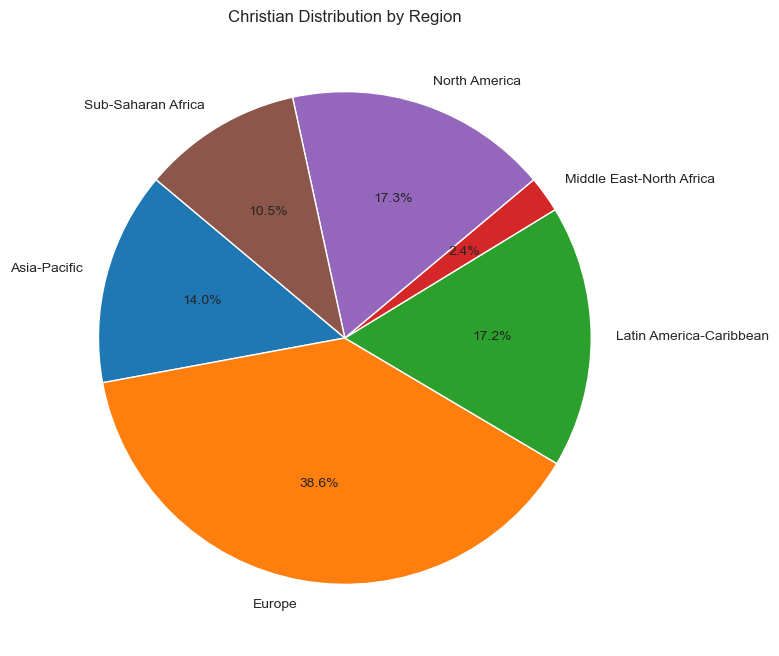

In [22]:
grouped_data_4 = Incoming_and_Outgoing_Migrant_Count.groupby(['Region', 'Religion'], as_index=False)['Count'].sum()
grouped_data_4 = grouped_data_4[grouped_data_4['Region'] != 'Global']
df_christian = grouped_data_4[grouped_data_4['Religion'] == 'Christian']
plt.figure(figsize=(8, 8))
plt.pie(df_christian['Count'], labels=df_christian['Region'], autopct='%1.1f%%', startangle=140)
plt.title('Christian Distribution by Region')
plt.show()

# Extra Credit (10%)

The best 10 visualizations and insights from Questions 2.2 to 2.4 will get an extra 20% credit (at most one visualization can be considered per submission). There is nothing you need to do for the extra credit except to do your best in the last three questions. We will showcase the best visualizations in class! 

This was the last part of Homework 2. Now you need to submit your work following the instructions in the beginning of the notebook and you are done!

# (10%) Part 3: Hypothesis testing 

### Let's experiment with Hypothesis testing. 

The goal is to test whether there is a difference in the two products' performance in the two conditions and recommend the better product.

Two products have been tested in two different experimental settings (or operating conditions) and the dataset is provided to you in p3c1.csv and p3c2.csv. Totally about 10000 tests were conducted.

An entry equal to 1 indicates that the product passed the test, and vice-versa.

Load the dataset first:


In [23]:
# Load datasets
df1 = pd.read_csv('p3c1.csv')

df2 = pd.read_csv('p3c2.csv')

print(df1.head(),'\n',df1.shape[0],'\n')

print(df2.head(),'\n',df2.shape[0],'\n')


   Unnamed: 0  prodA  prodB
0           0      1      1
1           1      1      1
2           2      1      1
3           3      1      1
4           4      1      0 
 10000 

   Unnamed: 0  prodA  prodB
0           0      1      1
1           1      1      0
2           2      0      0
3           3      1      0
4           4      1      0 
 10000 



## (6% points) Q3.1 We will create or write a function that takes in two samples and returns a p-value. 
I have given you the framework of this function. Note that ``norm.cdf(z) = P(Z < z)`` might be useful for calculating pvalue.

In [24]:
# 6 points for this function
def run_hypothesis_test(sampleA, sampleB):
    #pA =  # TODO: uncomment beginning and insert  code for mean of sampleA
    pA = np.mean(sampleA)
    #print(f"meanA:{pA}")
    #pB = # TODO: uncomment beginning and insert  code for mean of sampleB
    pB = np.mean(sampleB)
    #print(f"meanB:{pB}")
    #zhat = # TODO: uncomment beginning and insert code for zhat
    nA = len(sampleA)
    nB = len(sampleB)
    pA_1 = (pA*(1-pA))/nA
    pB_1 = (pB*(1-pB))/nB
    zhat = (pA - pB) / np.sqrt(pA_1+pB_1)

    pvalue =  2 * norm.sf(abs(zhat))# TODO: modify code for pValue

    return pvalue   

### (2% points) Q3.2 Now run your function on a set of samples from p3c1 and p3c2 and interpret the output. 

Clearly state the null hypothesis, pvalues of the two conditions and mention in which of the two conditions viz., c1 and c2, do you accept and reject null hypothesis. Which one is the better product?

In [25]:
# code to extract resuls of the two products from each condition
sampleA_1 = df1["prodA"]
sampleB_1 = df1["prodB"]

sampleA_2 = df2["prodA"]
sampleB_2 = df2["prodB"]

pvalue_1 = run_hypothesis_test(sampleA_1, sampleB_1)
pvalue_2 = run_hypothesis_test(sampleA_2, sampleB_2)
print(f"pvalue_1:{pvalue_1}")
print(f"pvalue_2:{pvalue_2}")

pvalue_1:0.027503898628231695
pvalue_2:2.2945100528546938e-06


(_Your Q3.2 answer here. Double click to edit_)
1. In the condition c1, pvalue_1<0.05,reject null hypothesis.product B better.
2. In the condition c2, pvalue_2<0.05,reject null hypothesis.product A better.

## (2% points) Q3.3 Run the analysis using your function 200 times by taking a subsample of 1000 results from each condition, how do your p-values vary?

Follow these directions: 

1. Since the order does not matter, you may sample each column of the individual dataframes separately. For this, ``pandas.DataFrame.sample`` function might be useful. 

    Calling the function ``pandas.DataFrame.sample`` with n=1000 gives you one subsample. You have to do this for each column of the two dataframes separately for 200 times.

2. Using subsample of the two products from each condition,  compute p-value using above function and append.



Create a histogram of pvalues from each run above. What do you notice?

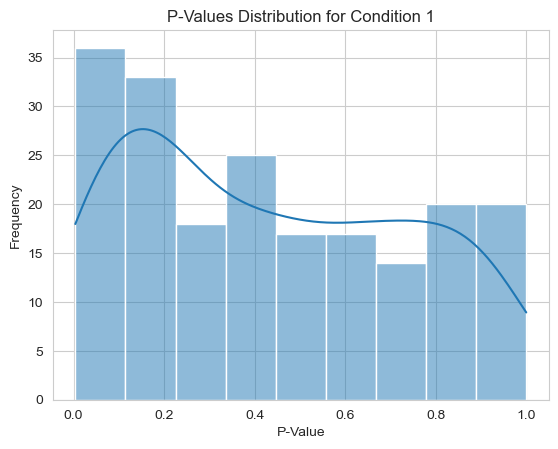

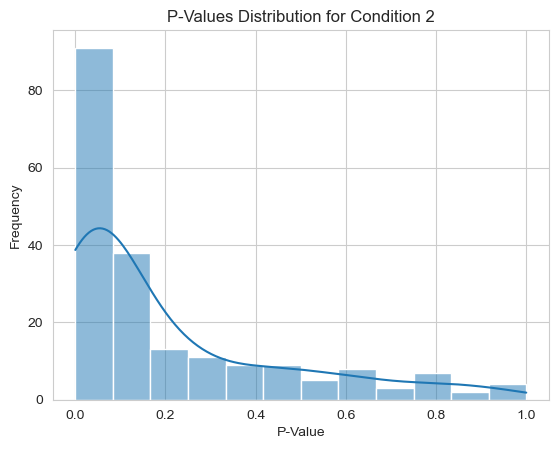

In [26]:
one_data_size = 1000
number_times = 200
pvalue1_list = []
pvalue2_list = []

for i in range(number_times):
    sampleA_1 = df1["prodA"].sample(n=one_data_size, replace=True)
    sampleB_1 = df1["prodB"].sample(n=one_data_size, replace=True)

    sampleA_2 = df2["prodA"].sample(n=one_data_size, replace=True)
    sampleB_2 = df2["prodB"].sample(n=one_data_size, replace=True)

    pvalue1 = run_hypothesis_test(sampleA_1,sampleB_1)
    pvalue1_list.append(pvalue1)

    pvalue2 = run_hypothesis_test(sampleA_2,sampleB_2)
    pvalue2_list.append(pvalue2)

sns.histplot(pvalue1_list, kde=True)
plt.title('P-Values Distribution for Condition 1')
plt.xlabel('P-Value')
plt.ylabel('Frequency')
plt.show()

sns.histplot(pvalue2_list, kde=True)
plt.title('P-Values Distribution for Condition 2')
plt.xlabel('P-Value')
plt.ylabel('Frequency')
plt.show()

(_Your Q3.3 answer here. Double click to edit_)

The most possbility of p-value is lower than 0.05.